# Welltory COVID-19 Data Exploration

This notebook explores data from the Welltory COVID-19 and Wearables Open Data Research dataset created in 2020.

The aim of the research study was to collect data on users with positive COVID-19 status.

All data has been downloaded from the [hrv-covid19 Github repository](https://github.com/Welltory/hrv-covid19) and moved into the `./hrv-covid19-master` folder 

In [12]:
# Import our packages
import requests
import pandas as pd
import matplotlib.pyplot as plt

## Blood Pressure Data Exploration

Let's start by analyzing the first data file in the `data` folder: `blood_pressure.csv`

In [13]:
import os
os.getcwd()

'/Users/ethancooley/Programming/Duke/AIPI 510 Sourcing Data/aipi510-fall25/data-exploration'

In [14]:
bp_df = pd.read_csv("../../hrv-covid19-master/blood_pressure.csv")
bp_df.head(10)

,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.40
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.00
5,01bad5a519,2020-05-01 09:58:06,80,130,NaN,NaN,NaN,NaN
6,01bad5a519,2020-05-01 11:29:18,80,122,2.73,3150.0,-7.0,91.50
7,01bad5a519,2020-05-01 14:29:18,80,122,NaN,NaN,NaN,NaN
8,01bad5a519,2020-05-03 08:28:30,76,112,2.60,2844.0,4.0,88.48
9,01bad5a519,2020-05-03 11:28:30,76,112,NaN,NaN,NaN,NaN


Let's print out some descriptive statistics

In [15]:
bp_df.describe()

,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
count,721.000000,721.000000,299.000000,299.000000,283.000000,299.000000
mean,81.228849,119.441054,2.594013,2735.197057,-15.498233,84.663779
std,8.865761,10.522578,0.291302,747.882570,18.681233,14.399208
min,25.000000,63.000000,1.680000,1300.000000,-76.000000,49.500000
25%,76.000000,113.000000,2.440000,2250.500000,-29.000000,75.580000
50%,82.000000,120.000000,2.580000,2640.000000,-17.000000,83.220000
75%,88.000000,126.000000,2.730000,3076.500000,-5.000000,93.170000
max,101.000000,157.000000,3.510000,7875.000000,45.000000,164.850000


What kind of data types are we working with in each column?

In [16]:
bp_df.dtypes

user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object

Notice there is a `user_code` column. Let's see how many users the data was collected on

In [17]:
bp_df["user_code"].value_counts()

user_code
a1c2e6b2eb    333
fde84801d8    128
6be5033971    105
cf7e50bcde     24
01bad5a519     23
295ed96279     22
1b9321b648     13
6ecfe4a351     10
7ba5381254      9
1ce1d77659      8
276ab22485      6
f9edcb7056      6
1ed25f66e9      6
8633d50fa7      4
0d297d2410      2
974d68bcdd      2
7d2c87fb7e      2
9871ee5e7b      2
588d6b2046      2
c1008ee281      2
f8b552df37      2
f922e9b06c      2
425969dc69      2
982ec78569      2
aa036185e3      1
ad41d5b79c      1
cdfbcad405      1
5108b04245      1
Name: count, dtype: int64

It looks like we only have a few users with a substantial amount of data points collected for us to properly map out a time series for them.

Let's create a line plot for the blood pressure of user `a1c2e6b2eb` as they have the most amount of values (`333`)

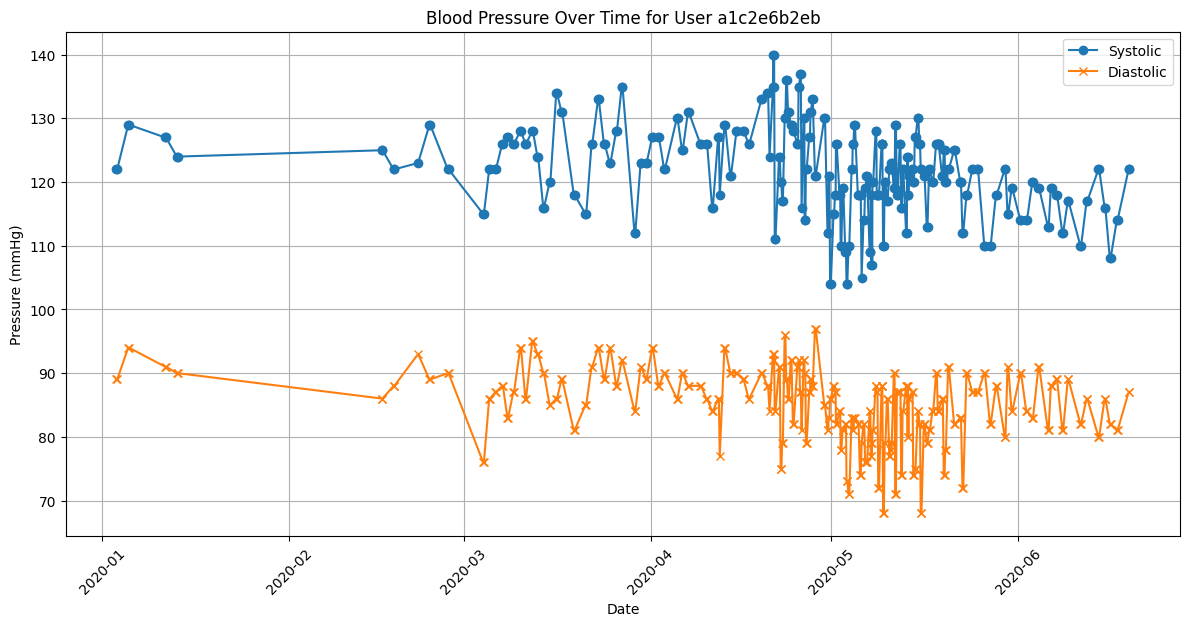

In [18]:
user_df = bp_df[bp_df['user_code'] == 'a1c2e6b2eb'].copy()

# Convert measurement_datetime to datetime
user_df['measurement_datetime'] = pd.to_datetime(user_df['measurement_datetime'])

# Sort by datetime
user_df = user_df.sort_values('measurement_datetime')

# Plot
plt.figure(figsize=(12, 6))
plt.plot(user_df['measurement_datetime'], user_df['systolic'], label='Systolic', marker='o')
plt.plot(user_df['measurement_datetime'], user_df['diastolic'], label='Diastolic', marker='x')

plt.title('Blood Pressure Over Time for User a1c2e6b2eb')
plt.xlabel('Date')
plt.ylabel('Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

What are some conclusions we can draw from this plot?
1. Systolic blood pressure starts at around `115-130 mmHg`, then spikes up to `140 mmHg` around mid-April. This can indicate some type of stressor or disease progression potentially stemming from Covid-19 prognosis. Afterward, it trends downward toward the `110-120` range, which indicates that the patient recovered back to what could be a baseline level.
2. Diastolic blood pressure starts around `90 mmHg`, then declines to around `80-90 mmHg` with fluctuations growing much larger after mid-April. This also can indicate some type of stressor the user's body was experiencing. We then see that it goes towards a steady range around June.
3. Overall: greater variability between both systolic and diastolic blood pressure starting at the mid-April mark. This could indicate a number of issues such as cardiovascular stress, compensatory response to disease or infection, or physiological stress. All of these could be the result of the user's positive Covid-19 diagnosis. Furthermore, we see that blood pressure returns to a level of normalcy around the June mark, indicating the patient's potential recovery to baseline.

Let's further analyze some of the values in our dataframe such as `functional_changes_index`, `circulatory_efficiency`, `kerdo_vegetation_index`, and `robinson_index`.
But first, what do these values mean? 
- **Functional changes index**: Measures the overall adaptation level or stress load on the body based on heart rate variability (HRV), BP, and other parameters.
- **Circulatory efficiency**: An indicator of how effectively the cardiovascular system supplies oxygen and nutrients and removes waste products.
- **Kerdo Vegetative Index**: Assesses the balance between sympathetic and parasympathetic activity (autonomic nervous system balance).
- **Robinson Index**: An estimate of myocardial oxygen consumption (heart workload).

Let's map these values over our original systolic and diastolic plot. But first, let's assess the data quality because based off the original dataframe inspection there seemed to be a lot of values missing!

### Missing values analysis

In [19]:
bp_df.isna().sum()

user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64

In [20]:
len(bp_df)

721

That's a total of ~422 values missing out of all 721 rows! It's ok though, we should still be able to get a good idea of how the patient's vitals were during the time series. We will just drop all missing values.

In [21]:
user_df = user_df.dropna(subset=["functional_changes_index", "circulatory_efficiency", "kerdo_vegetation_index", "robinson_index"])

Now let's plot out these new columns.

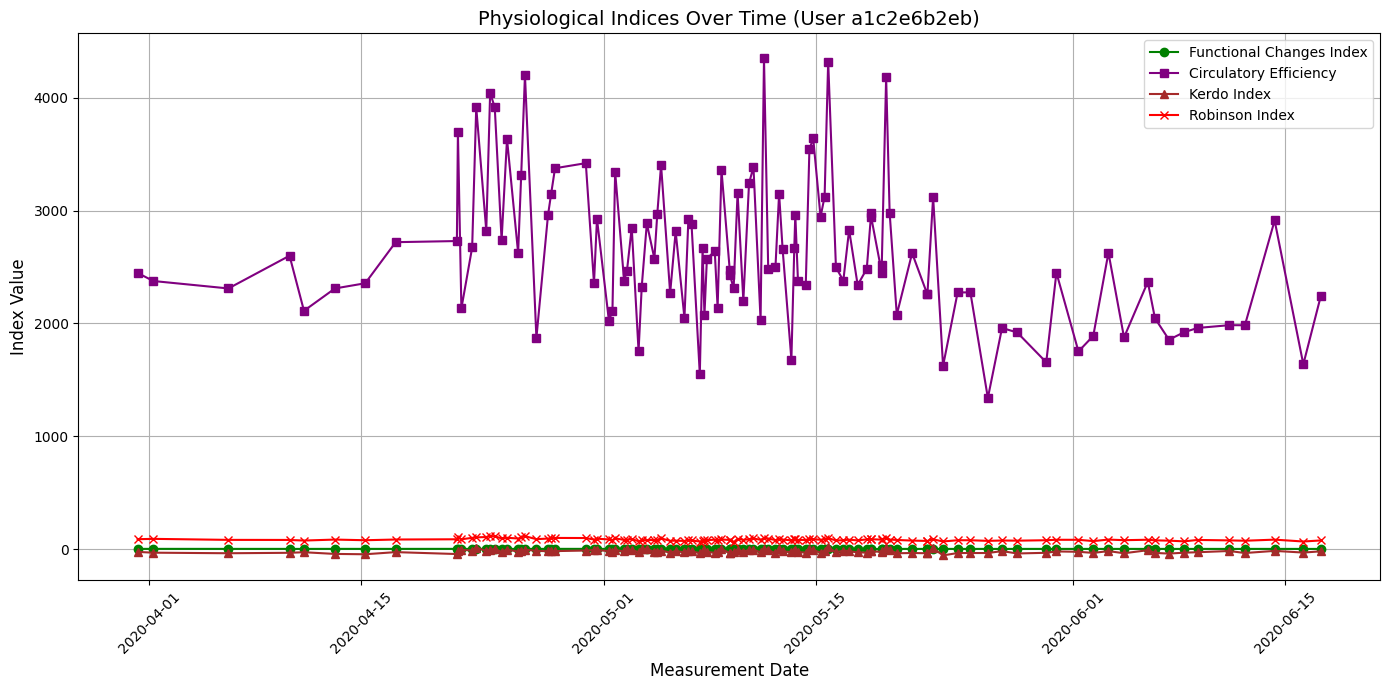

In [22]:
plt.figure(figsize=(14, 7))

plt.plot(user_df['measurement_datetime'], user_df['functional_changes_index'],
         label='Functional Changes Index', color='green', marker='o')

plt.plot(user_df['measurement_datetime'], user_df['circulatory_efficiency'],
         label='Circulatory Efficiency', color='purple', marker='s')

plt.plot(user_df['measurement_datetime'], user_df['kerdo_vegetation_index'],
         label='Kerdo Index', color='brown', marker='^')

plt.plot(user_df['measurement_datetime'], user_df['robinson_index'],
         label='Robinson Index', color='red', marker='x')

# Labels and formatting
plt.title('Physiological Indices Over Time (User a1c2e6b2eb)', fontsize=14)
plt.xlabel('Measurement Date', fontsize=12)
plt.ylabel('Index Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

### Data normalization

That's pretty difficult to read. So let's normalize the data using min-max scaling.

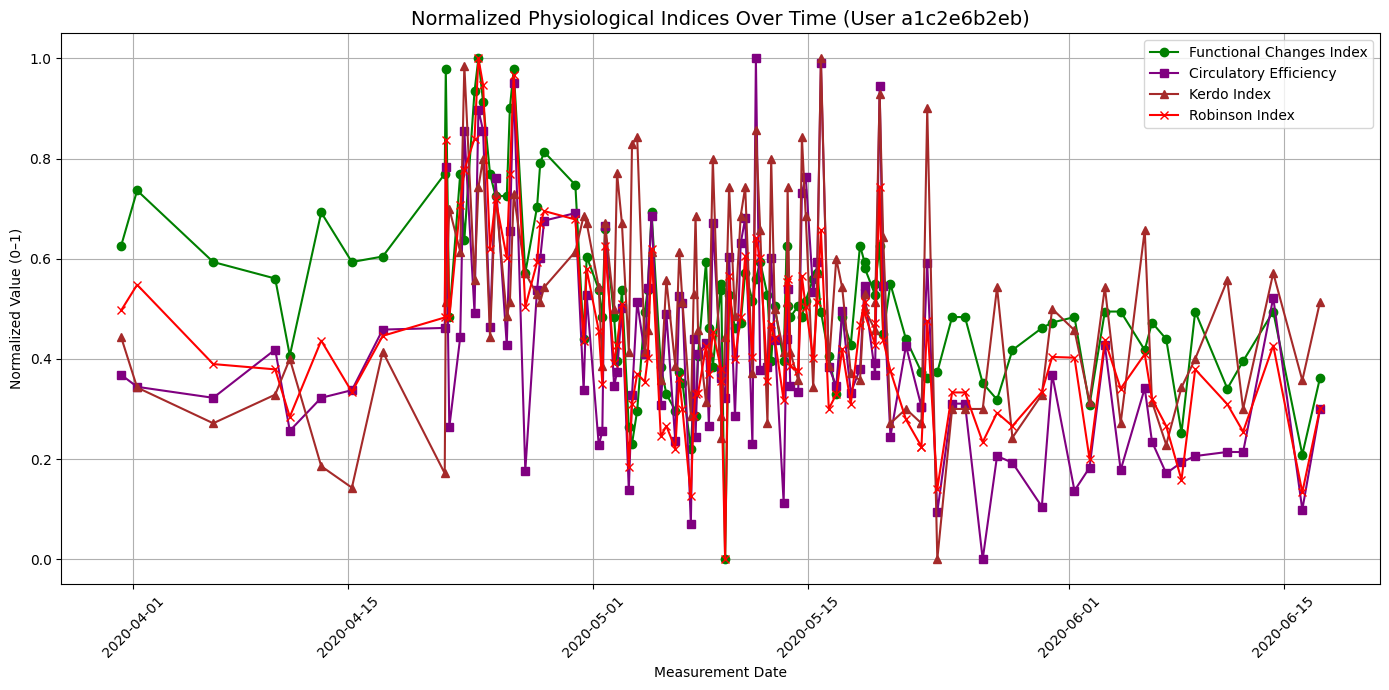

In [23]:
for col in [
    'functional_changes_index',
    'circulatory_efficiency',
    'kerdo_vegetation_index',
    'robinson_index'
]:
    min_val = user_df[col].min()
    max_val = user_df[col].max()
    user_df[col] = (user_df[col] - min_val) / (max_val - min_val)

# Step 3: Plot normalized values
plt.figure(figsize=(14, 7))

plt.plot(user_df['measurement_datetime'], user_df['functional_changes_index'],
         label='Functional Changes Index', color='green', marker='o')

plt.plot(user_df['measurement_datetime'], user_df['circulatory_efficiency'],
         label='Circulatory Efficiency', color='purple', marker='s')

plt.plot(user_df['measurement_datetime'], user_df['kerdo_vegetation_index'],
         label='Kerdo Index', color='brown', marker='^')

plt.plot(user_df['measurement_datetime'], user_df['robinson_index'],
         label='Robinson Index', color='red', marker='x')

# Labels and formatting
plt.title('Normalized Physiological Indices Over Time (User a1c2e6b2eb)', fontsize=14)
plt.xlabel('Measurement Date')
plt.ylabel('Normalized Value (0–1)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This is much easier to analyze!

As we can see, there is a downward trend in all physiological measuremenets starting around the late April mark. This tracks accurately with the conclusions we came to earlier when analyzing the systolic and diastolic blood pressure measurements. It is clear that for this positive Covid-19 patient, the symptoms began around late April and cardiovascular health took a hit. Then afterwards around June, their cardiovascular health returned to a lower and more normal level with much less radical fluctuations.

### Feature engineering

Let's engineer a new feature for further analysis. We will create a new column called `pulse_pressure`. Pulse pressure is the difference between systolic and diastolic blood pressures. It reflects the force with which the heart pumps blood and the elasticity of the arteries. 

Since higher pulse pressure usally indicates stiff arteries and elevated cardiovascular stress, this feature will give us an even better idea about how efficient the patient's heart was working as they battled through Covid-19.

In [24]:
user_df['pulse_pressure'] = user_df['systolic'] - user_df['diastolic']

We are going to choose to compare this value with the patient's Robinson Index, as that is a solid measurement of their overall stress during this time period.
We will follow a similar process of normalizing the data and plotting the two columns alongside one another.

This will tell us not only that pulse pressure is a reliable engineered feature, but also that there should be a correlation between the two variables if they both are accurate heart health measurements.

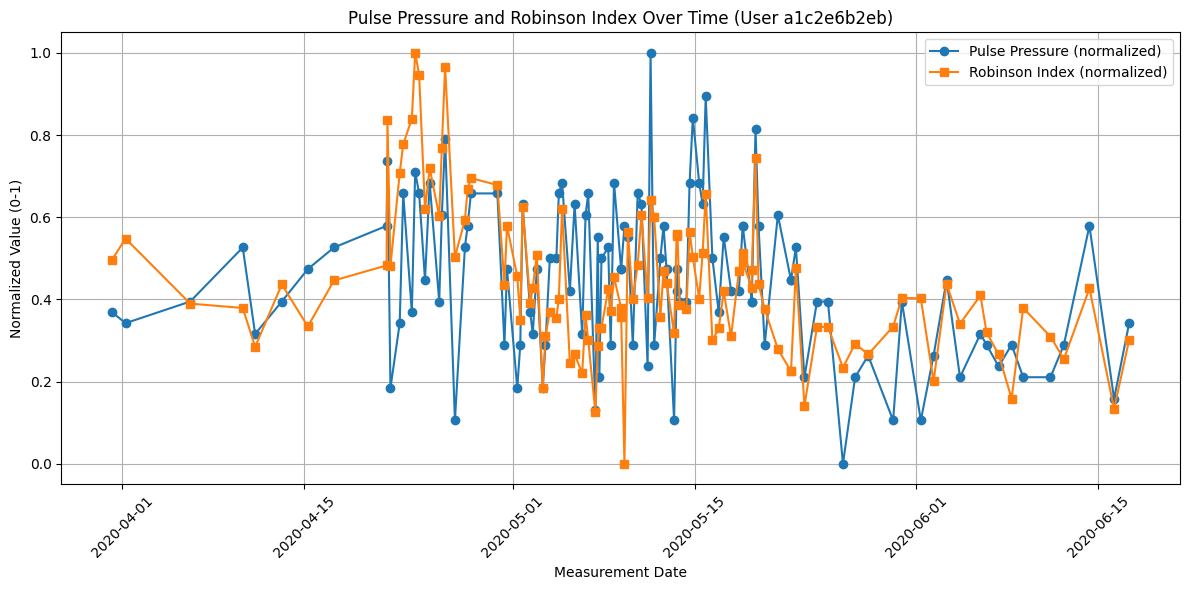

In [25]:
# Normalize pulse pressure since robinson index is already normalized
min_val = user_df["pulse_pressure"].min()
max_val = user_df["pulse_pressure"].max()
user_df["pulse_pressure"] = (user_df["pulse_pressure"] - min_val) / (max_val - min_val)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(user_df['measurement_datetime'], user_df['pulse_pressure'], label='Pulse Pressure (normalized)', marker='o')
plt.plot(user_df['measurement_datetime'], user_df['robinson_index'], label='Robinson Index (normalized)', marker='s')

plt.title('Pulse Pressure and Robinson Index Over Time (User a1c2e6b2eb)')
plt.xlabel('Measurement Date')
plt.ylabel('Normalized Value (0-1)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see, both pulse pressure and the Robinson Index have a massive increase right around mid to late April. This tracks with everything we have seen so far, and proves that the patient's cardiovascular system was undergoing stress and that they likely had Covid-19 during this team period. 

We can also see that pulse pressure and the Robinson Index follow each other nicely, showing a moderate correlation. 

If we want to go further, we can look at the quantitative (not just visual) correlation between our newly engineered feature `pulse_pressure` and `functional_changes_index` to see if everything is still tracking smoothly. 

In [26]:
user_df[['pulse_pressure', 'robinson_index']].corr()

,pulse_pressure,robinson_index
pulse_pressure,1.000000,0.542763
robinson_index,0.542763,1.000000


As we can see, we have a correlation of 0.54 between pulse pressure and robinson index. This indicates a **moderate positive correlation**, which is quite meaningful especially considering this is clinical data where correlations rarely reach high values due to complexity and noise.

### Comparing with other users

One thing I am curious about is how the pulse pressure over time looks like for other users in this dataset. From our value counts analysis we did earlier, we can see that user `fde84801d8` has `128` rows, and user `6be5033971` has `105` rows. This should be sufficient to compare the three users.

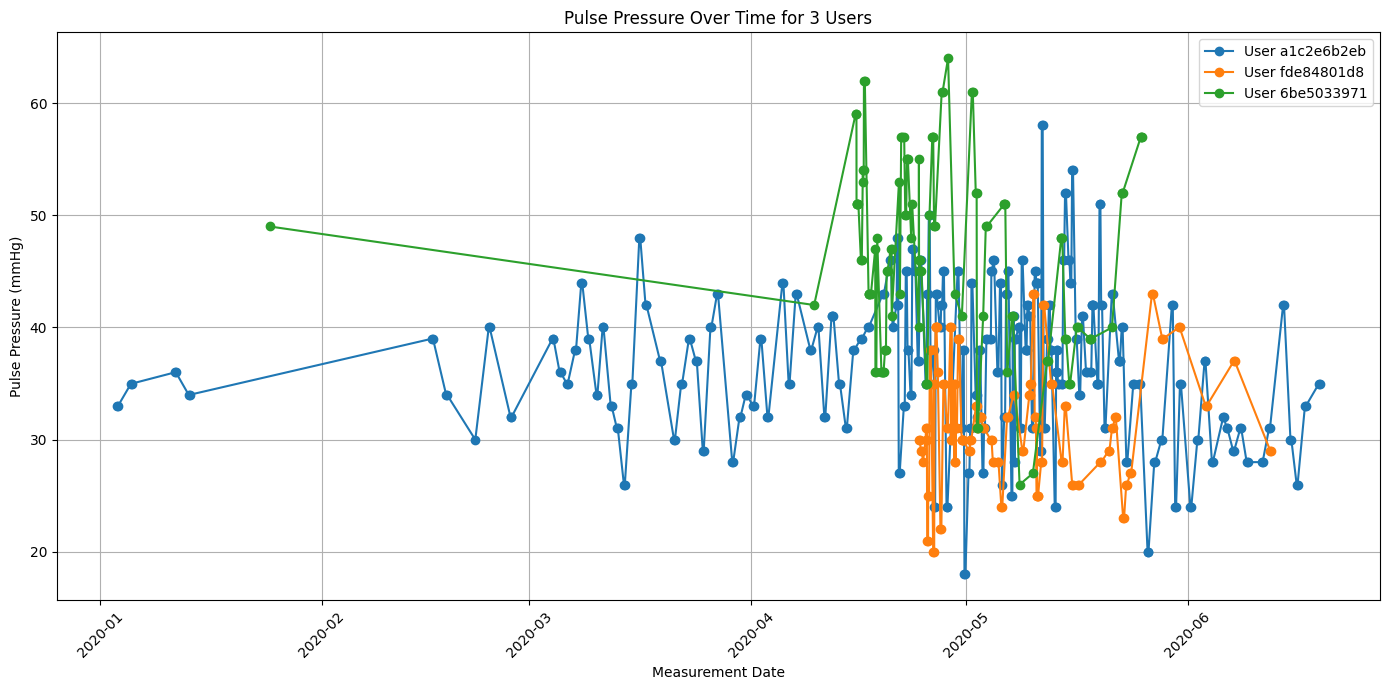

In [27]:
user_codes = ['a1c2e6b2eb', 'fde84801d8', '6be5033971']

# Filter only those users
users_df = bp_df[bp_df['user_code'].isin(user_codes)].copy()
users_df['measurement_datetime'] = pd.to_datetime(users_df['measurement_datetime'])

# Compute pulse pressure
users_df['pulse_pressure'] = users_df['systolic'] - users_df['diastolic']

# Drop rows with missing values in pulse pressure
users_df = users_df.dropna(subset=['pulse_pressure'])

# Sort by time
users_df = users_df.sort_values(['user_code', 'measurement_datetime'])

# Plotting
plt.figure(figsize=(14, 7))

for user_code in user_codes:
    user_data = users_df[users_df['user_code'] == user_code]
    plt.plot(user_data['measurement_datetime'], user_data['pulse_pressure'],
             marker='o', label=f'User {user_code}')

plt.title('Pulse Pressure Over Time for 3 Users')
plt.xlabel('Measurement Date')
plt.ylabel('Pulse Pressure (mmHg)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Interestingly, all three users seem to have taken a dramatic hit around mid to late April, as we can see the pulse pressure dramatically increase. Afterwards, however, it appears to return to baseline indicating possible recovery.

## Overall

* Analyzed time series blood pressure and physiological data for user `a1c2e6b2eb` which indicated a dramatic spike in cardiovascular stress around mid to late April. Likely stemming from Covid-19.
* Reviewed missing values and dropped all rows where data was insufficient.
* Normalized data columns `Functional Changes Index`, `Circulatory Efficiency`, `Kerdo Vegetation Index`, `Robinson Index` for easier analysis.
* Created a new feature `Pulse Pressure` which showed a moderate positive correlation `~0.54` with the `Robinson Index`, reflecting cardiovascular workload.
* A slight downward trend in phsyiological health metrics suggested possible recovery or reduced cardiovascular stress over time. 
* Compared `Pulse Pressure` over time for three different users, showing that they all appeared to get sick with Covid-19 around the same time.